##### ### The University of Melbourne, School of Computing and Information Systems
# COMP30027 Machine Learning, 2026 Semester 1

## Assignment 1: Income Classification with Naïve Bayes


**Student ID(s):**     `1610754`


This iPython notebook is a template which you will use for your Assignment 1 submission.

**NOTE: YOU SHOULD ADD YOUR RESULTS, GRAPHS, AND FIGURES FROM YOUR OBSERVATIONS IN THIS FILE TO YOUR REPORT (the PDF file).** Results, figures, etc. which appear in this file but are NOT included in your report will not be marked.

**Adding proper comments to your code is MANDATORY. **

## Setup and Preprocesing


In [284]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ( 
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

In [285]:
DATA_DIR = "Assignment1_data"

CATEGORICAL_FEATURES = [
    "education", "marital-status", "native-country", "occupation",
    "race", "relationship", "sex", "workclass"
]
CONTINUOUS_FEATURES = [
    "age", "capital-gain", "capital-loss", "education-num",
    "hours-per-week"
]

ALL_FEATURES = CATEGORICAL_FEATURES + CONTINUOUS_FEATURES

INCOME = "income"


## Data Preprocessing


In [286]:
def load_and_clean(path: str, has_label: bool = True) -> tuple:

    df = pd.read_csv(path)

    # Replace both '?' and ' ?' (with leading space) with NaN
    df = df.replace("?", np.nan)
    df = df.replace(" ?", np.nan)

    # Drop any row with a missing feature value
    df = df.dropna(subset=ALL_FEATURES)
    df = df.reset_index(drop=True)

    X = df[ALL_FEATURES].copy()


    for col in CONTINUOUS_FEATURES:
        X[col] = pd.to_numeric(X[col])
    for col in CATEGORICAL_FEATURES:
        X[col] = X[col].astype(str).str.strip()

    if has_label:
        y = df[INCOME].astype(str).str.strip()
        return X, y
    return X, None

In [287]:
# Load only the supervised training data needed for Task 1
X_train_full, y_train_full = load_and_clean(f'{DATA_DIR}/adult_supervised_train.csv')

print(f'Supervised train : {len(X_train_full)} rows')

# Carve out 15% as a validation set 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full,
)
print(f'\nTraining (after val split) : {len(X_train)} rows')
print(f'Validation: {len(X_val)} rows')

Supervised train : 15076 rows

Training (after val split) : 12060 rows
Validation: 3016 rows


In [288]:
# Check class imbalance 
print('Class distribution in trainin set:')
print(y_train_full.value_counts(normalize=True).map('{:.1%}'.format))


# Summary statistics for continuous features
X_train_full.describe()

Class distribution in trainin set:
income
<=50K    75.4%
>50K     24.6%
Name: proportion, dtype: str


,age,capital-gain,capital-loss,education-num,hours-per-week
count,15076.000000,15076.000000,15076.000000,15076.000000,15076.000000
mean,38.744362,1005.850226,91.969422,10.112497,40.956487
std,13.290810,6970.042555,411.093674,2.561602,11.860822
min,17.000000,0.000000,0.000000,1.000000,1.000000
25%,28.000000,0.000000,0.000000,9.000000,40.000000
50%,37.000000,0.000000,0.000000,10.000000,40.000000
75%,48.000000,0.000000,0.000000,13.000000,45.000000
max,90.000000,99999.000000,3770.000000,16.000000,99.000000


## 1. Supervised model training


In [289]:
class MixedNaiveBayes:
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.gnb = GaussianNB()
        self.cnb = CategoricalNB(alpha=alpha)
        self.encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    def fit(self, X, y):
        self.gnb.fit(X[CONTINUOUS_FEATURES].values, y)
        
        X_cat = self.encoder.fit_transform(X[CATEGORICAL_FEATURES])
        # shift by 1: unknown=-1 → 0 (dedicated UNK slot), real categories → 1+
        X_cat = (X_cat + 1).astype(int)
        self.cnb.fit(X_cat, y)                               

       
        self.classes_    = list(self.gnb.classes_)
        self.log_prior_  = {c: float(np.log(self.gnb.class_prior_[i]))
                            for i, c in enumerate(self.classes_)}
        self.gauss_mean_ = {c: {feat: float(self.gnb.theta_[i, j])
                                for j, feat in enumerate(CONTINUOUS_FEATURES)}
                            for i, c in enumerate(self.classes_)}
        self.gauss_var_  = {c: {feat: float(self.gnb.var_[i, j])
                                for j, feat in enumerate(CONTINUOUS_FEATURES)}
                            for i, c in enumerate(self.classes_)}
        return self

    def encode_categorical(self, X):
        X_cat = self.encoder.transform(X[CATEGORICAL_FEATURES])
        return (X_cat + 1).astype(int)

    def log_proba(self, X):
        log_gnb = self.gnb.predict_log_proba(X[CONTINUOUS_FEATURES].values)
        log_cnb = self.cnb.predict_log_proba(self.encode_categorical(X))
        return log_gnb + log_cnb - np.log(self.gnb.class_prior_)

    def predict_proba(self, X):
        log_prob = self.log_proba(X)                         
        log_prob -= log_prob.max(axis=1, keepdims=True)
        p = np.exp(log_prob)
        return p / p.sum(axis=1, keepdims=True)              

    def predict(self, X):
        log_prob = self.log_proba(X)                         
        return np.array([self.classes_[i] for i in log_prob.argmax(axis=1)])  
    
    def confidence_ratio(self, X):
        log_prob = self.log_proba(X)
        r = np.exp(log_prob[:, 1] - log_prob[:, 0])       
        r[np.isinf(r)] = np.nan
        return r

    def predict_top_categories(self, c1_idx=1, c2_idx=0, top_n=5):
        rows = []
        for fi, feat in enumerate(CATEGORICAL_FEATURES):
            log_prob = self.cnb.feature_log_prob_[fi]
            # index 0 is the UNK slot; real categories start at shifted index 1
            for vi, v in enumerate(self.encoder.categories_[fi]):
                shifted_idx = vi + 1
                rows.append((feat, v, float(np.exp(log_prob[c1_idx, shifted_idx] - log_prob[c2_idx, shifted_idx]))))
        rows.sort(key=lambda x: -x[2])
        return rows[:top_n]

In [290]:
model = MixedNaiveBayes(alpha=1.0)
model.fit(X_train_full, y_train_full)
print("Model trained on full supervised set.")

Model trained on full supervised set.


In [291]:
raw = {}
rows = []
for feat in CONTINUOUS_FEATURES:
    for c in model.classes_:
        mean = model.gauss_mean_[c][feat]
        var  = model.gauss_var_[c][feat]
        std  = np.sqrt(var)
        raw[(feat, c)] = {'mean': mean, 'var': var}
        rows.append({'Feature': feat, 'Class': c,
                     'Mean': f'{mean:.2f}', 'Std': f'{std:.2f}'})

df_params = pd.DataFrame(rows).pivot(
    index='Feature', columns='Class', values=['Mean', 'Std'])

df_params.columns = [f'{stat}_{cls}' for stat, cls in df_params.columns]
df_params.columns.name = None
df_params = df_params.reset_index()

c1, c2 = model.classes_[0], model.classes_[1]
mean_diff, sep = [], []
for f in df_params['Feature']:
    m1, m2 = raw[(f, c1)]['mean'], raw[(f, c2)]['mean']
    v1, v2 = raw[(f, c1)]['var'], raw[(f, c2)]['var']
    d = abs(m1 - m2)
    mean_diff.append(d)
    sep.append(d / np.sqrt(v1 + v2))
df_params['mean_difference'] = mean_diff
df_params['separation_score'] = sep
df_params = df_params.sort_values('separation_score', ascending=False)
df_params['mean_difference'] = df_params['mean_difference'].map(lambda x: f'{x:.4f}')
df_params['separation_score'] = df_params['separation_score'].map(lambda x: f'{x:.4f}')

df_params.index = [''] * len(df_params)
df_params

,Feature,Mean_<=50K,Mean_>50K,Std_<=50K,Std_>50K,mean_difference,separation_score
,education-num,9.63,11.59,2.45,2.36,1.9653,0.5774
,age,37.05,43.94,13.71,10.30,6.8877,0.4016
,hours-per-week,39.43,45.64,11.91,10.40,6.2137,0.3930
,capital-gain,157.67,3607.15,1017.86,13616.62,3449.4807,0.2526
,capital-loss,55.97,202.36,316.02,603.99,146.3874,0.2147


In [292]:
def top_categories_df(rows):
    df = pd.DataFrame(rows, columns=["Feature", "Value", "R"])
    df["R"] = df["R"].map(lambda x: f"{x:.4f}")
    df.index = [""] * len(df)
    return df


def best_per_feature(model, c1_idx, c2_idx):
    best = {}
    for fi, feat in enumerate(CATEGORICAL_FEATURES):
        log_prob = model.cnb.feature_log_prob_[fi]
        best_r, best_v = -np.inf, None
        for vi, v in enumerate(model.encoder.categories_[fi]):
            shifted_idx = vi + 1  # skip UNK slot at index 0
            r_log = float(log_prob[c1_idx, shifted_idx] - log_prob[c2_idx, shifted_idx])
            if r_log > best_r:
                best_r, best_v = r_log, v
        best[feat] = (best_v, np.exp(best_r))
    return best


# class order should be ['<=50K', '>50K'] in this notebook
c_pos = model.classes_[1]  # >50K
c_neg = model.classes_[0]  # <=50K

best_pos = best_per_feature(model, c1_idx=1, c2_idx=0)
best_neg = best_per_feature(model, c1_idx=0, c2_idx=1)

per_feat_rows = []
for feat in CATEGORICAL_FEATURES:
    v_pos, r_pos = best_pos[feat]
    v_neg, r_neg = best_neg[feat]
    per_feat_rows.append({
        "Feature": feat,
        f"Best value ({c_pos})": v_pos,
        f"R ({c_pos})": f"{r_pos:.4f}",
        f"Best value ({c_neg})": v_neg,
        f"R ({c_neg})": f"{r_neg:.4f}",
    })

df_per_feat = pd.DataFrame(per_feat_rows)
df_per_feat.index = [""] * len(df_per_feat)
print("Most predictive value per feature, per class:")
display(df_per_feat)

print(f"Top 5 most predictive of {c_pos}:")
display(top_categories_df(model.predict_top_categories(c1_idx=1, c2_idx=0, top_n=5)))

print(f"Top 5 most predictive of {c_neg}:")
display(top_categories_df(model.predict_top_categories(c1_idx=0, c2_idx=1, top_n=5)))

Most predictive value per feature, per class:


,Feature,Best value (>50K),R (>50K),Best value (<=50K),R (<=50K)
,education,Prof-school,7.9572,9th,6.6306
,marital-status,Married-AF-spouse,4.2874,Never-married,6.1054
,native-country,Taiwan,3.3825,Mexico,5.4683
,occupation,Exec-managerial,2.7680,Priv-house-serv,11.9337
,race,Asian-Pac-Islander,1.1320,Amer-Indian-Eskimo,2.2677
,relationship,Wife,2.7445,Own-child,19.1714
,sex,Male,1.3780,Female,2.5180
,workclass,Self-emp-inc,3.2504,Private,1.1669


Top 5 most predictive of >50K:


,Feature,Value,R
,education,Prof-school,7.9572
,education,Doctorate,7.1341
,marital-status,Married-AF-spouse,4.2874
,education,Masters,3.5545
,native-country,Taiwan,3.3825


Top 5 most predictive of <=50K:


,Feature,Value,R
,relationship,Own-child,19.1714
,occupation,Priv-house-serv,11.9337
,occupation,Other-service,7.3844
,relationship,Other-relative,6.9213
,education,9th,6.6306


## 2. Supervised model evaluation

Test accuracy: 0.8306

              precision    recall  f1-score   support

       <=50K       0.85      0.93      0.89     11303
        >50K       0.72      0.53      0.61      3784

    accuracy                           0.83     15087
   macro avg       0.79      0.73      0.75     15087
weighted avg       0.82      0.83      0.82     15087



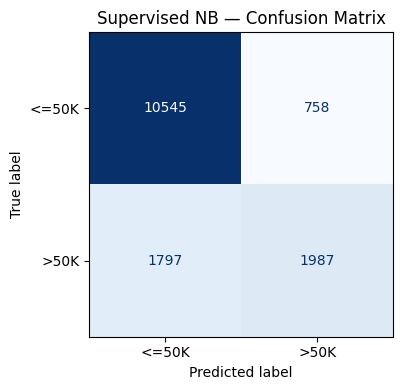

Test instances with >=1 unseen category value: 1 (0.0%)

Unseen categories in test row 3100:
  - native-country: Holand-Netherlands


In [293]:
X_test, y_test = load_and_clean(f'{DATA_DIR}/adult_test.csv')
y_pred = model.predict(X_test)
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, zero_division=0))


# confusion matrix
cm   = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Supervised NB — Confusion Matrix')
plt.tight_layout()
plt.show()

raw = model.encoder.transform(X_test[CATEGORICAL_FEATURES])
oov_mask = (raw == -1).any(axis=1)
print(f'Test instances with >=1 unseen category value: '
      f'{oov_mask.sum()} ({100*oov_mask.sum()/len(X_test):.1f}%)')


if oov_mask.any():
    oov_rows = np.where(oov_mask)[0]
    for ridx in oov_rows:
        unseen_cols = np.where(raw[ridx] == -1)[0]
        print(f'\nUnseen categories in test row {ridx}:')
        for cidx in unseen_cols:
            feat = CATEGORICAL_FEATURES[cidx]
            val = X_test.iloc[ridx][feat]
            print(f'  - {feat}: {val}')

In [294]:
# Compute the posterior ratio R = P(>50K|x) / P(<=50K|x) for every test instance
ratios = model.confidence_ratio(X_test)
X_te = X_test.reset_index(drop=True)
y_te = y_test.reset_index(drop=True)
y_pr = pd.Series(y_pred).reset_index(drop=True)

DISPLAY_COLS = ['age', 'education', 'occupation', 'marital-status']

def make_table(indices):
    records = []
    for i in indices:
        row = {'R': ratios[i], 'pred': y_pr[i], 'true': y_te[i]}
        for col in DISPLAY_COLS:
            row[col] = X_te.iloc[i][col]
        records.append(row)
    df = pd.DataFrame(records)
    df['R'] = df['R'].map(lambda x: f'{x:.4g}')
    df.index = [''] * len(df)
    return df

# --- (a) High-confidence >50K: highest R among instances predicted >50K ---
high_50k_idx = [i for i in np.argsort(-ratios) if y_pr[i] == '>50K'][:3]
print('(a) High-confidence >50K predictions:')
display(make_table(high_50k_idx))

# --- (b) High-confidence <=50K: lowest R among instances predicted <=50K ---
low_50k_idx = [i for i in np.argsort(ratios) if y_pr[i] == '<=50K'][:3]
print('(b) High-confidence <=50K predictions:')
display(make_table(low_50k_idx))

# --- (c) Boundary cases: R closest to 1 (|log R| ≈ 0) ---
log_r = np.abs(np.log(ratios + 1e-9))
boundary_idx = list(np.argsort(log_r)[:3])
print('(c) Boundary cases (R ≈ 1):')
display(make_table(boundary_idx))

(a) High-confidence >50K predictions:


/var/folders/8_/yd0n4sbd60b6sn2p9brdfjpw0000gn/T/ipykernel_9913/2473779954.py:50: RuntimeWarning: overflow encountered in exp
  r = np.exp(log_prob[:, 1] - log_prob[:, 0])


,R,pred,true,age,education,occupation,marital-status
,1.21e+160,>50K,>50K,51,Prof-school,Prof-specialty,Divorced
,1.29e+159,>50K,>50K,37,Masters,Exec-managerial,Separated
,9.305e+158,>50K,>50K,53,Prof-school,Prof-specialty,Never-married


(b) High-confidence <=50K predictions:


,R,pred,true,age,education,occupation,marital-status
,9.229e-10,<=50K,<=50K,18,10th,Other-service,Never-married
,1.073e-09,<=50K,<=50K,17,10th,Other-service,Never-married
,1.106e-09,<=50K,<=50K,17,11th,Other-service,Never-married


(c) Boundary cases (R ≈ 1):


,R,pred,true,age,education,occupation,marital-status
,0.9999,<=50K,>50K,29,Bachelors,Exec-managerial,Married-civ-spouse
,1.002,>50K,<=50K,38,7th-8th,Farming-fishing,Married-civ-spouse
,0.9958,<=50K,>50K,33,Bachelors,Prof-specialty,Married-civ-spouse


## 3. Extending the model with semi-supervised training

In [295]:
X_unlabelled, _ = load_and_clean(f'{DATA_DIR}/adult_unlabelled.csv', has_label=False)
_, y_unlabelled_true = load_and_clean(f'{DATA_DIR}/adult_unlabelled_with_labels.csv')
print(f'Unlabelled pool: {len(X_unlabelled)} instances')

Unlabelled pool: 15059 instances


In [296]:
base_model = MixedNaiveBayes(alpha=1.0)
base_model.fit(X_train, y_train)

ratios_al  = base_model.confidence_ratio(X_unlabelled)
unc_scores = np.abs(np.log(ratios_al + 1e-9))
unc_order  = np.argsort(unc_scores)

rng = np.random.default_rng(42)
N_SELECT = 200

/var/folders/8_/yd0n4sbd60b6sn2p9brdfjpw0000gn/T/ipykernel_9913/2473779954.py:50: RuntimeWarning: overflow encountered in exp
  r = np.exp(log_prob[:, 1] - log_prob[:, 0])


In [297]:
#random slection
random_idx = rng.choice(len(X_unlabelled), size=N_SELECT, replace=False)

X_random = pd.concat([
    X_train.reset_index(drop=True),
    X_unlabelled.iloc[random_idx].reset_index(drop=True)
], ignore_index=True)
y_random = pd.concat([
    y_train.reset_index(drop=True),
    y_unlabelled_true.iloc[random_idx].reset_index(drop=True)
], ignore_index=True)

random_model = MixedNaiveBayes(alpha=1.0)
random_model.fit(X_random, y_random)
print(f'Random model trained on {len(X_random)} instances')

Random model trained on 12260 instances


In [298]:
uncertainty_idx = unc_order[:N_SELECT]

X_uncertainty = pd.concat([
    X_train.reset_index(drop=True),
    X_unlabelled.iloc[uncertainty_idx].reset_index(drop=True)
], ignore_index=True)
y_uncertainty = pd.concat([
    y_train.reset_index(drop=True),
    y_unlabelled_true.iloc[uncertainty_idx].reset_index(drop=True)
], ignore_index=True)


uncertainty_model = MixedNaiveBayes(alpha=1.0)
uncertainty_model.fit(X_uncertainty, y_uncertainty)


In [299]:
from sklearn.metrics import precision_recall_fscore_support

RANDOM_TRIALS = 5
RANDOM_SEED = 42
DIVERSE_CANDIDATES = 500 

def get_metrics(y_true, y_pred):
    labels = ['<=50K', '>50K']
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1.mean(),
        'f1_<=50K': f1[0],
        'f1_>50K': f1[1],
        'precision_<=50K': p[0],
        'recall_<=50K': r[0],
        'precision_>50K': p[1],
        'recall_>50K': r[1],
    }

def select_uncertainty_diverse_idx(base_model, X_pool, unc_scores, n_select, n_candidates=1000):
    n_candidates = min(n_candidates, len(X_pool))
    candidate_idx = np.argsort(unc_scores)[:n_candidates]
    X_cand = X_pool.iloc[candidate_idx]

    # Continuous features are z-scored, then combined with encoded categorical features.
    X_cont = X_cand[CONTINUOUS_FEATURES].to_numpy(dtype=float)
    cont_std = X_cont.std(axis=0)
    cont_std[cont_std == 0] = 1.0
    X_cont = (X_cont - X_cont.mean(axis=0)) / cont_std

    X_cat = base_model.encode_categorical(X_cand).astype(float)
    X_mix = np.hstack([X_cont, X_cat])

    # Greedy farthest-first traversal with uncertainty-favored initial point.
    local_start = int(np.argmin(unc_scores[candidate_idx]))
    selected_local = [local_start]

    all_local = np.arange(len(candidate_idx))
    min_d2 = np.sum((X_mix - X_mix[local_start]) ** 2, axis=1)

    while len(selected_local) < n_select:
        min_d2[selected_local] = -1.0
        next_local = int(np.argmax(min_d2))
        selected_local.append(next_local)
        d2_next = np.sum((X_mix - X_mix[next_local]) ** 2, axis=1)
        min_d2 = np.minimum(min_d2, d2_next)

    return candidate_idx[np.array(selected_local)]

# 1) Baseline on the 80/20 split
y_pred_base = base_model.predict(X_val)
baseline_metrics = get_metrics(y_val, y_pred_base)

# 2) Random (+200), averaged across 5 trials
rng = np.random.default_rng(RANDOM_SEED)
random_runs = []

for _ in range(RANDOM_TRIALS):
    random_idx = rng.choice(len(X_unlabelled), size=N_SELECT, replace=False)

    X_random = pd.concat(
        [X_train.reset_index(drop=True), X_unlabelled.iloc[random_idx].reset_index(drop=True)],
        ignore_index=True
    )
    y_random = pd.concat(
        [y_train.reset_index(drop=True), y_unlabelled_true.iloc[random_idx].reset_index(drop=True)],
        ignore_index=True
    )

    random_model = MixedNaiveBayes(alpha=1.0)
    random_model.fit(X_random, y_random)

    y_pred_random = random_model.predict(X_val)
    random_runs.append(get_metrics(y_val, y_pred_random))

random_avg_metrics = pd.DataFrame(random_runs).mean().to_dict()

# 3) Uncertainty (+200)
uncertainty_idx = unc_order[:N_SELECT]

X_unc = pd.concat(
    [X_train.reset_index(drop=True), X_unlabelled.iloc[uncertainty_idx].reset_index(drop=True)],
    ignore_index=True
)
y_unc = pd.concat(
    [y_train.reset_index(drop=True), y_unlabelled_true.iloc[uncertainty_idx].reset_index(drop=True)],
    ignore_index=True
)

uncertainty_model = MixedNaiveBayes(alpha=1.0)
uncertainty_model.fit(X_unc, y_unc)

y_pred_unc = uncertainty_model.predict(X_val)
uncertainty_metrics = get_metrics(y_val, y_pred_unc)

# 4) Uncertainty + diversity (+200)
uncertainty_diverse_idx = select_uncertainty_diverse_idx(
    base_model,
    X_unlabelled,
    unc_scores,
    N_SELECT,
    n_candidates=DIVERSE_CANDIDATES,
)

X_unc_div = pd.concat(
    [X_train.reset_index(drop=True), X_unlabelled.iloc[uncertainty_diverse_idx].reset_index(drop=True)],
    ignore_index=True
)
y_unc_div = pd.concat(
    [y_train.reset_index(drop=True), y_unlabelled_true.iloc[uncertainty_diverse_idx].reset_index(drop=True)],
    ignore_index=True
)

uncertainty_diverse_model = MixedNaiveBayes(alpha=1.0)
uncertainty_diverse_model.fit(X_unc_div, y_unc_div)

y_pred_unc_div = uncertainty_diverse_model.predict(X_val)
uncertainty_diverse_metrics = get_metrics(y_val, y_pred_unc_div)

results = pd.DataFrame([
    {'policy': 'baseline', **baseline_metrics},
    {'policy': 'random_average', **random_avg_metrics},
    {'policy': 'uncertainty', **uncertainty_metrics},
    {'policy': 'uncertainty_diverse', **uncertainty_diverse_metrics},
])

metric_cols = [
    'accuracy', 'macro_f1', 'f1_<=50K', 'f1_>50K',
    'precision_<=50K', 'recall_<=50K', 'precision_>50K', 'recall_>50K'
]
results[metric_cols] = results[metric_cols].round(4)

print('Validation results for active-learning policies:')
print(results.to_string(index=False))

chosen_approach = results.sort_values('macro_f1', ascending=False).iloc[0]['policy']
print(f'\nChosen approach based on validation macro-F1: {chosen_approach}')

# Reveal labels for selected 200; fit final_model on full supervised data + those 200 (Q4/Q5 use test set).
if chosen_approach == 'uncertainty':
    selected_idx = uncertainty_idx
    selected_abs_log_R = unc_scores[selected_idx]
elif chosen_approach == 'uncertainty_diverse':
    selected_idx = uncertainty_diverse_idx
    selected_abs_log_R = unc_scores[selected_idx]
else:
    selected_idx = np.random.default_rng(RANDOM_SEED).choice(
        len(X_unlabelled), size=N_SELECT, replace=False
    )
    selected_abs_log_R = None

X_selected = X_unlabelled.iloc[selected_idx].reset_index(drop=True)
y_selected = y_unlabelled_true.iloc[selected_idx].reset_index(drop=True)

# Final model: full supervised training set + 200 labeled pool points (then evaluate on test).
X_train_augmented = pd.concat(
    [X_train_full.reset_index(drop=True), X_selected],
    ignore_index=True,
)
y_train_augmented = pd.concat(
    [y_train_full.reset_index(drop=True), y_selected],
    ignore_index=True,
)

final_model = MixedNaiveBayes(alpha=1.0)
final_model.fit(X_train_augmented, y_train_augmented)

selected_counts = y_selected.value_counts().reindex(['<=50K', '>50K']).fillna(0).astype(int)
selected_summary = pd.DataFrame({
    'class': selected_counts.index,
    'count': selected_counts.values,
    'proportion': (selected_counts / selected_counts.sum()).values,
})

print('\nFinal selected 200 instances from the real unlabeled pool:')
print(selected_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

if selected_abs_log_R is not None:
    print(f'Mean |log R| of selected instances: {selected_abs_log_R.mean():.4f}')

Validation results for active-learning policies:
             policy  accuracy  macro_f1  f1_<=50K  f1_>50K  precision_<=50K  recall_<=50K  precision_>50K  recall_>50K
           baseline    0.8296    0.7471    0.8915   0.6028           0.8571        0.9288          0.7065       0.5256
     random_average    0.8295    0.7471    0.8915   0.6028           0.8572        0.9286          0.7061       0.5259
        uncertainty    0.8296    0.7477    0.8914   0.6040           0.8577        0.9279          0.7050       0.5283
uncertainty_diverse    0.8299    0.7478    0.8917   0.6039           0.8575        0.9288          0.7071       0.5270

Chosen approach based on validation macro-F1: uncertainty_diverse

Final selected 200 instances from the real unlabeled pool:
class  count  proportion
<=50K    109      0.5450
 >50K     91      0.4550
Mean |log R| of selected instances: 0.2599


## 4. Semi-Supervised model evaluation

Q4 compares the supervised baseline model from Q1 (`model`) against the final semi-supervised model from Q3 (`final_model`) on the test set.


Q4 test-set performance comparison:
          model  accuracy  macro_f1  precision_<=50K  recall_<=50K  f1_<=50K  precision_>50K  recall_>50K  f1_>50K
  Supervised NB    0.8306    0.7503           0.8544        0.9329    0.8919          0.7239       0.5251   0.6087
Active learning    0.8310    0.7511           0.8549        0.9328    0.8922          0.7243       0.5270   0.6101


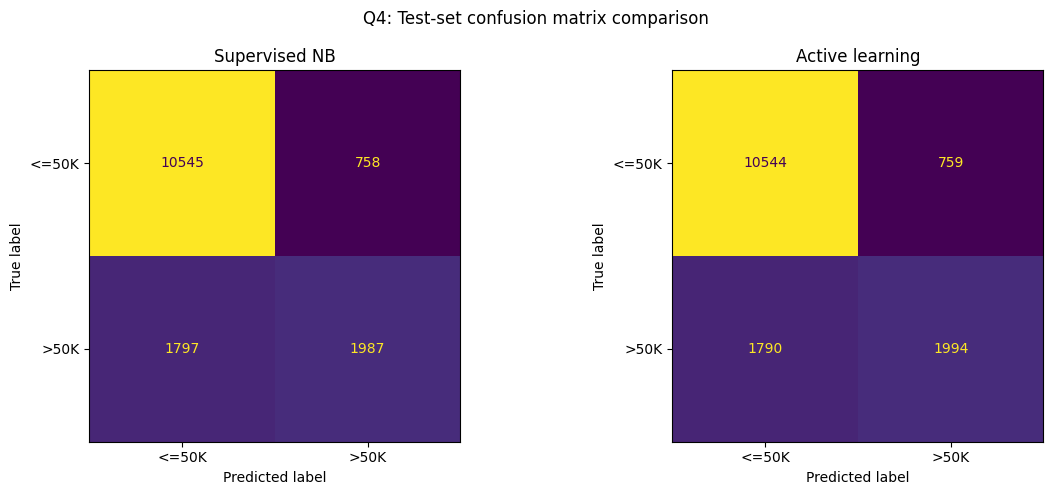


Q4 concise interpretation:
- Better overall model by accuracy: Active learning
- Accuracy change: +0.0004
- Macro F1 change: +0.0008
- Class F1 change for <=50K: +0.0002
- Class F1 change for >50K: +0.0014


In [300]:
# Q4: Compare supervised (Q1) and semi-supervised (Q3) models on test data

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# 1) Prerequisite and sanity checks
# -----------------------------
required_vars = ["model", "final_model", "X_test", "y_test"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing variables required for Q4: {missing}. "
        "Please run data loading, Q1, and Q3 cells first."
    )

if len(X_test) != len(y_test):
    raise ValueError(f"Test size mismatch: len(X_test)={len(X_test)}, len(y_test)={len(y_test)}")

# Use a fixed class order to keep all evaluations consistent
classes = np.array(["<=50K", ">50K"])

# -----------------------------
# 2) Predictions
# -----------------------------
y_pred_sup = model.predict(X_test)
y_pred_semi = final_model.predict(X_test)

# -----------------------------
# 3) Metrics table
# -----------------------------
def collect_metrics(model_name, y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    out = {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
    }

    for i, cls in enumerate(labels):
        out[f"precision_{cls}"] = precision[i]
        out[f"recall_{cls}"] = recall[i]
        out[f"f1_{cls}"] = f1[i]

    return out

comparison_df = pd.DataFrame(
    [
        collect_metrics("Supervised NB", y_test, y_pred_sup, classes),
        collect_metrics("Active learning", y_test, y_pred_semi, classes),
    ]
)

metric_cols = [
    "model",
    "accuracy",
    "macro_f1",
    "precision_<=50K",
    "recall_<=50K",
    "f1_<=50K",
    "precision_>50K",
    "recall_>50K",
    "f1_>50K",
]

print("Q4 test-set performance comparison:")
print(comparison_df[metric_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# -----------------------------
# 4) Consistency checks
# -----------------------------
acc_sup_direct = np.mean(np.asarray(y_pred_sup) == np.asarray(y_test))
acc_semi_direct = np.mean(np.asarray(y_pred_semi) == np.asarray(y_test))

assert np.isclose(acc_sup_direct, comparison_df.loc[0, "accuracy"]), "Supervised accuracy mismatch"
assert np.isclose(acc_semi_direct, comparison_df.loc[1, "accuracy"]), "Semi-supervised accuracy mismatch"

cm_sup = confusion_matrix(y_test, y_pred_sup, labels=classes)
cm_semi = confusion_matrix(y_test, y_pred_semi, labels=classes)

assert cm_sup.sum() == len(y_test), "Supervised confusion matrix total mismatch"
assert cm_semi.sum() == len(y_test), "Semi-supervised confusion matrix total mismatch"

# -----------------------------
# 5) Side-by-side confusion matrices
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_sup, display_labels=classes).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Supervised NB")

ConfusionMatrixDisplay(cm_semi, display_labels=classes).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Active learning")

plt.suptitle("Q4: Test-set confusion matrix comparison")
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Auto interpretation (based on observed results)
# -----------------------------
sup_row = comparison_df.loc[comparison_df["model"] == "Supervised NB"].iloc[0]
semi_row = comparison_df.loc[comparison_df["model"] == "Active learning"].iloc[0]

better_model = "Active learning" if semi_row["accuracy"] >= sup_row["accuracy"] else "Supervised NB"

delta_acc = semi_row["accuracy"] - sup_row["accuracy"]
delta_macro_f1 = semi_row["macro_f1"] - sup_row["macro_f1"]
delta_f1_le = semi_row["f1_<=50K"] - sup_row["f1_<=50K"]
delta_f1_gt = semi_row["f1_>50K"] - sup_row["f1_>50K"]

print("\nQ4 concise interpretation:")
print(f"- Better overall model by accuracy: {better_model}")
print(f"- Accuracy change: {delta_acc:+.4f}")
print(f"- Macro F1 change: {delta_macro_f1:+.4f}")
print(f"- Class F1 change for <=50K: {delta_f1_le:+.4f}")
print(f"- Class F1 change for >50K: {delta_f1_gt:+.4f}")

In [301]:
# Q9: Top categorical predictors per class (likelihood ratio R from CategoricalNB)
TOP_N = 5

print("\nQ9 — Supervised NB")
print("Top values most predictive of >50K (R = p(v|>50K) / p(v|<=50K)):")
display(top_categories_df(model.predict_top_categories(c1_idx=1, c2_idx=0, top_n=TOP_N)))
print("Top values most predictive of <=50K (R = p(v|<=50K) / p(v|>50K)):")
display(top_categories_df(model.predict_top_categories(c1_idx=0, c2_idx=1, top_n=TOP_N)))

print("\nQ9 — Active learning (final_model)")
print("Top values most predictive of >50K:")
display(top_categories_df(final_model.predict_top_categories(c1_idx=1, c2_idx=0, top_n=TOP_N)))
print("Top values most predictive of <=50K:")
display(top_categories_df(final_model.predict_top_categories(c1_idx=0, c2_idx=1, top_n=TOP_N)))



Q9 — Supervised NB
Top values most predictive of >50K (R = p(v|>50K) / p(v|<=50K)):


,Feature,Value,R
,education,Prof-school,7.9572
,education,Doctorate,7.1341
,marital-status,Married-AF-spouse,4.2874
,education,Masters,3.5545
,native-country,Taiwan,3.3825


Top values most predictive of <=50K (R = p(v|<=50K) / p(v|>50K)):


,Feature,Value,R
,relationship,Own-child,19.1714
,occupation,Priv-house-serv,11.9337
,occupation,Other-service,7.3844
,relationship,Other-relative,6.9213
,education,9th,6.6306



Q9 — Active learning (final_model)
Top values most predictive of >50K:


,Feature,Value,R
,education,Prof-school,7.7587
,education,Doctorate,7.0692
,marital-status,Married-AF-spouse,4.2250
,education,Masters,3.4761
,workclass,Self-emp-inc,3.3038


Top values most predictive of <=50K:


,Feature,Value,R
,relationship,Own-child,18.9469
,occupation,Priv-house-serv,12.1095
,occupation,Other-service,7.5074
,relationship,Other-relative,7.0567
,education,9th,6.7282


### Q4 conclusion (concise)

Based on the test-set metrics and confusion matrices above:

- State which model is better overall (`Supervised NB` or `Active learning`) using accuracy and macro-F1.
- State which class (`<=50K` or `>50K`) improved or degraded most using class-wise F1.
- Briefly justify the trend: the `Active learning` (Q3) model uses pseudo-labelled unlabelled examples, which can improve generalisation if selected labels are reliable.

Use the printed deltas from the Q4 code cell to support your conclusion with exact values.